In [192]:
Subject='P13'
# 选择并绘制第一环节生成的健康侧脚踝 mocap 重力方向加速度信号
MOCAP_SUBJECT = f'{Subject}'
MOCAP_CANE_CONDITION = 'with_cane'  # 可选 'with_cane' 或 'without_cane'
MOCAP_SIGNAL_INDEX = 3           # 选择下方列出的对应文件
MOCAP_X_RANGE = None    # 例如 (7, 20)；None 表示显示全部时间
PEAK_MIN_DISTANCE_S = 0.3  # 相邻候选峰的最小时间间隔（秒）

In [193]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FS = 100
DATA_DIR = Path('/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data')
gravity_filter_path = DATA_DIR / f'Data_for_Align/IMU/{Subject}_GravityFilter.csv'
if not gravity_filter_path.exists():
    raise FileNotFoundError(
        f'未找到 {gravity_filter_path}，请先运行 Process copy525 _without_gait.ipynb。'
    )
display_columns = [
    'elapsed (s)',
    'S1_linacc_gravity_filtered',
    'S2_linacc_gravity_filtered',
    'S6_linacc_gravity_filtered',
]
df = pd.read_csv(gravity_filter_path, usecols=display_columns)
print(f'已加载重力补偿数据: {gravity_filter_path.name}')

已加载重力补偿数据: P13_GravityFilter.csv


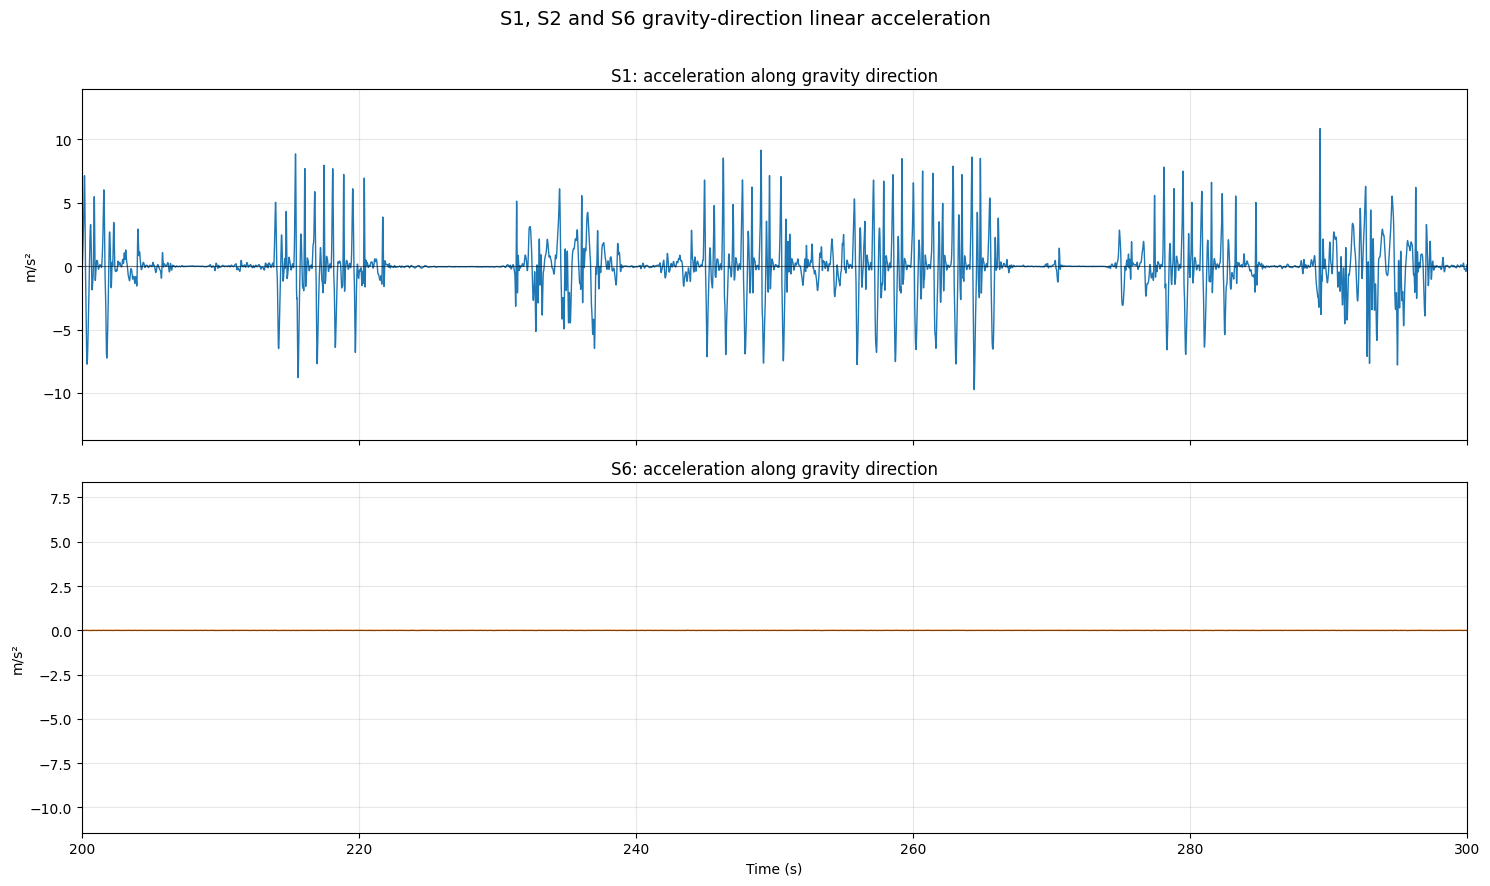

In [194]:
# 展示 S1、S2、S6 在瞬时重力方向上的线性加速度
plot_sensors = ['S1', 'S6']
gravity_columns = [f'{sensor}_linacc_gravity_filtered' for sensor in plot_sensors]
missing_columns = [column for column in gravity_columns if column not in df.columns]
if missing_columns:
    raise KeyError(f'缺少重力方向加速度列，请先运行上一个重力补偿单元: {missing_columns}')

if 'elapsed (s)' in df.columns:
    plot_time = df['elapsed (s)'].to_numpy(dtype=float)
    x_label = 'Time (s)'
else:
    plot_time = np.arange(len(df), dtype=float) / FS
    x_label = 'Time (s, derived from sample index)'

fig, axes = plt.subplots(len(plot_sensors), 1, figsize=(15, 9), sharex=True)
colors = ['tab:blue', 'tab:orange', 'tab:green']
for ax, sensor, column, color in zip(axes, plot_sensors, gravity_columns, colors):
    ax.plot(plot_time, df[column].to_numpy(dtype=float), color=color, linewidth=1.0)
    ax.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{sensor}: acceleration along gravity direction')
    ax.set_ylabel('m/s²')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel(x_label)
axes[-1].set_xlim(200,300)  # 调整这里的起止时间（秒）来设置 x 轴范围
fig.suptitle('S1, S2 and S6 gravity-direction linear acceleration', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()





可选 mocap 信号：subject=P13, condition=with_cane
  0: P13_with_cane_hemi130101_healthy_R_toe_gravity_acceleration.csv
  1: P13_with_cane_hemi130102_healthy_R_toe_gravity_acceleration.csv
  2: P13_with_cane_hemi130103_healthy_R_toe_gravity_acceleration.csv
  3: P13_with_cane_hemi130104_healthy_R_toe_gravity_acceleration.csv
  4: P13_with_cane_hemi130105_healthy_R_toe_gravity_acceleration.csv
已选择: P13_with_cane_hemi130104_healthy_R_toe_gravity_acceleration.csv | with cane | with_cane=True


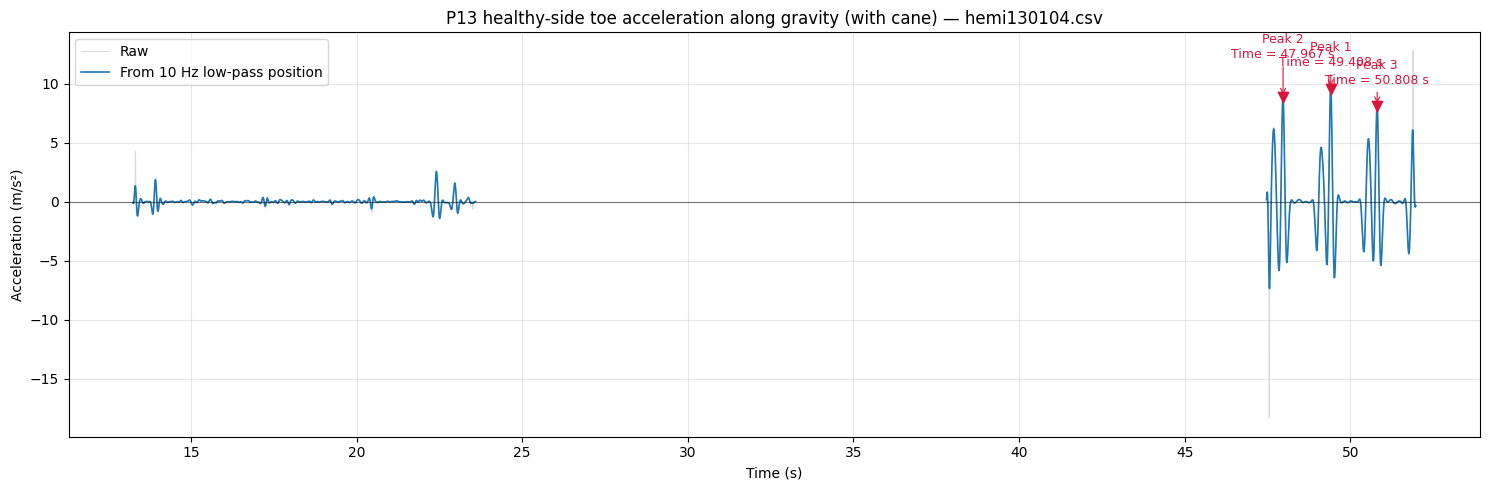

x 轴范围 [0.000, 53.217] s 内的最大峰值：
  Peak 1: Time=49.408 s, Acceleration=9.5643 m/s²
  Peak 2: Time=47.967 s, Acceleration=8.8423 m/s²
  Peak 3: Time=50.808 s, Acceleration=8.1056 m/s²


In [195]:
from scipy.signal import find_peaks

valid_cane_conditions = {'with_cane', 'without_cane'}
if MOCAP_CANE_CONDITION not in valid_cane_conditions:
    raise ValueError(f'MOCAP_CANE_CONDITION 必须是 {sorted(valid_cane_conditions)}')

mocap_signal_dir = DATA_DIR / 'Data_for_Align/Mocap'
signal_pattern = (
    f'{MOCAP_SUBJECT}_{MOCAP_CANE_CONDITION}_*_toe_gravity_acceleration.csv'
)
available_mocap_signals = sorted(mocap_signal_dir.glob(signal_pattern))
if not available_mocap_signals:
    raise FileNotFoundError(
        f'未找到 {MOCAP_SUBJECT} / {MOCAP_CANE_CONDITION} 的 mocap 信号；'
        '请检查 Data_for_Align 或运行 Process525_mocap_all_subjects_gravity_acceleration.ipynb。'
    )

print(f'可选 mocap 信号：subject={MOCAP_SUBJECT}, condition={MOCAP_CANE_CONDITION}')
for index, path in enumerate(available_mocap_signals):
    print(f'  {index}: {path.name}')
if not 0 <= MOCAP_SIGNAL_INDEX < len(available_mocap_signals):
    raise IndexError(
        f'MOCAP_SIGNAL_INDEX={MOCAP_SIGNAL_INDEX} 超出范围 0-{len(available_mocap_signals) - 1}'
    )

selected_mocap_path = available_mocap_signals[MOCAP_SIGNAL_INDEX]
mocap_signal = pd.read_csv(selected_mocap_path)
selected_condition = str(mocap_signal['cane_condition'].iloc[0])
with_cane_value = mocap_signal['with_cane'].iloc[0]
uses_cane = str(with_cane_value).strip().lower() in {'true', '1'}
if selected_condition != MOCAP_CANE_CONDITION:
    raise ValueError(
        f'文件 condition={selected_condition} 与选择的 {MOCAP_CANE_CONDITION} 不一致'
    )
condition_label = 'with cane' if uses_cane else 'without cane'
print(f'已选择: {selected_mocap_path.name} | {condition_label} | with_cane={uses_cane}')
time_s = mocap_signal['time_s'].to_numpy(dtype=float)
raw_acceleration = mocap_signal['healthy_toe_gravity_acceleration_m_s2'].to_numpy(dtype=float)
filtered_acceleration = mocap_signal['healthy_toe_gravity_acceleration_filtered_m_s2'].to_numpy(dtype=float)

# 仅在当前选择的 x 轴范围内寻找局部峰，并按峰高选取前三个
if MOCAP_X_RANGE is None:
    x_min, x_max = np.nanmin(time_s), np.nanmax(time_s)
else:
    x_min, x_max = sorted(map(float, MOCAP_X_RANGE))
finite_time_steps = np.diff(time_s[np.isfinite(time_s)])
finite_time_steps = finite_time_steps[finite_time_steps > 0]
if len(finite_time_steps) == 0:
    raise ValueError('时间轴中没有有效的递增采样点。')
sample_interval_s = float(np.median(finite_time_steps))
minimum_peak_distance = max(1, int(round(PEAK_MIN_DISTANCE_S / sample_interval_s)))
peak_search_mask = (
    np.isfinite(time_s)
    & np.isfinite(filtered_acceleration)
    & (time_s >= x_min)
    & (time_s <= x_max)
)
peak_search_signal = np.full_like(filtered_acceleration, -np.inf)
peak_search_signal[peak_search_mask] = filtered_acceleration[peak_search_mask]
candidate_peak_indices, _ = find_peaks(
    peak_search_signal, distance=minimum_peak_distance
)
candidate_peak_indices = candidate_peak_indices[peak_search_mask[candidate_peak_indices]]
top_peak_indices = candidate_peak_indices[
    np.argsort(filtered_acceleration[candidate_peak_indices])[::-1][:3]
]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(time_s, raw_acceleration, color='lightgray', linewidth=0.8, alpha=0.8, label='Raw')
ax.plot(time_s, filtered_acceleration, color='tab:blue', linewidth=1.2, label='From 10 Hz low-pass position')
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.set_title(
    f'{MOCAP_SUBJECT} healthy-side toe acceleration along gravity '
    f'({condition_label}) — {mocap_signal["source_file"].iloc[0]}'
)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration (m/s²)')
ax.grid(True, alpha=0.3)
for rank, peak_index in enumerate(top_peak_indices, start=1):
    peak_time = time_s[peak_index]
    peak_value = filtered_acceleration[peak_index]
    ax.scatter(peak_time, peak_value, color='crimson', marker='v', s=55, zorder=5)
    ax.annotate(
        f'Peak {rank}\nTime = {peak_time:.3f} s',
        xy=(peak_time, peak_value),
        xytext=(0, 14 + 12 * ((rank - 1) % 2)),
        textcoords='offset points', ha='center', va='bottom',
        color='crimson', fontsize=9,
        arrowprops={'arrowstyle': '->', 'color': 'crimson', 'lw': 0.8},
    )
ax.legend()
if MOCAP_X_RANGE is not None:
    ax.set_xlim(x_min, x_max)
fig.tight_layout()
plt.show()

if len(top_peak_indices) == 0:
    print(f'在 x 轴范围 [{x_min:.3f}, {x_max:.3f}] s 内未检测到局部峰值。')
else:
    print(f'x 轴范围 [{x_min:.3f}, {x_max:.3f}] s 内的最大峰值：')
    for rank, peak_index in enumerate(top_peak_indices, start=1):
        print(
            f'  Peak {rank}: Time={time_s[peak_index]:.3f} s, '
            f'Acceleration={filtered_acceleration[peak_index]:.4f} m/s²'
        )
